# Pythonセミナー第9回：QM9のHOMO-LUMOギャップ予測

このノートブックは、配布されたSMILESだけから特徴量を生成し、`gap_eV` を予測します。

外部データ、事前学習済みモデル、LLM、NNPは使用しません。

評価指標はMAE、乱数シードはスライド推奨の8、提出ファイルは `smiles,gap_eV` の2列とします。

In [ ]:
# 数値計算、表形式データ、可視化に使うライブラリを読み込む
from pathlib import Path
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit
import seaborn as sns
import sklearn
import xgboost as xgb
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Descriptors, rdFingerprintGenerator
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# スライドで推奨されている乱数シード8を、分割とモデルの両方に使用する
SEED = 8
np.random.seed(SEED)

# ノートブックをプロジェクト直下から実行する前提で入出力パスを定義する
PROJECT_DIR = Path.cwd()
TRAIN_PATH = PROJECT_DIR / "qm9_bandgap_train.csv"
TEST_PATH = PROJECT_DIR / "qm9_bandgap_test_without_answer.csv"
SUBMISSION_PATH = PROJECT_DIR / "submissionv1.csv"

# 再現性を確認できるように、実行環境と主要ライブラリの版を表示する
print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"RDKit: {rdkit.__version__}")
print(f"XGBoost: {xgb.__version__}")

Python: 3.11.15
pandas: 3.0.3
scikit-learn: 1.9.0
RDKit: 2026.03.4
XGBoost: 3.2.0


## 1. 配布CSVの読込と検査

訓練データは `smiles,gap_eV`、テストデータは `smiles` の列を持つことを確認します。

同じ分子が訓練側と検証側へ分かれるとMAEが過度によく見えるため、Canonical SMILESを使って重複も調べます。

In [2]:
# 配布されたCSVだけを読み込み、外部データは追加しない
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# スライドで指定された列構造になっているかを早い段階で検査する
assert train_df.columns.tolist() == ["smiles", "gap_eV"]
assert test_df.columns.tolist() == ["smiles"]
assert train_df["smiles"].notna().all()
assert train_df["gap_eV"].notna().all()
assert test_df["smiles"].notna().all()

# 行数、目的変数の範囲、先頭行を表示してデータの読込結果を確認する
print(f"訓練データ: {train_df.shape}")
print(f"テストデータ: {test_df.shape}")
print(
    "gap_eVの範囲: "
    f"{train_df['gap_eV'].min():.6f} ～ {train_df['gap_eV'].max():.6f} eV"
)
display(train_df.head())
display(test_df.head())

訓練データ: (15000, 2)
テストデータ: (4000, 1)
gap_eVの範囲: 1.774183 ～ 10.718570 eV


,smiles,gap_eV
0,C#CC1(CNC1=O)C#C,7.094012
1,CC1CC=CCOC=N1,6.854552
2,CC1=C2CCC3C(C1)C23,5.839566
3,COC(=O)CN1CC1C,6.658630
4,OC1CC23CCCC12O3,8.364784


,smiles
0,CC1(CN1)C(C#C)C#N
1,C1CC11C2OC2C11CO1
2,OC1CC1C1CC(O)C1
3,OC1C=CC2COC12
4,CC1OC1CNC(N)=O


In [3]:
# SMILESをRDKitで読み、同じ分子を同じ文字列にそろえる関数を定義する
def canonicalize_smiles(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKitで解釈できないSMILESです: {smiles}")
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)


# 訓練データとテストデータを同じ規則でCanonical SMILESへ変換する
train_df["canonical_smiles"] = train_df["smiles"].map(canonicalize_smiles)
test_df["canonical_smiles"] = test_df["smiles"].map(canonicalize_smiles)

# 同じ分子に異なる正解値が付いていないことを確認する
target_counts = train_df.groupby("canonical_smiles")["gap_eV"].nunique()
assert target_counts.max() == 1

# 重複分子数と、訓練データとテストデータの重なりを確認する
duplicate_rows = int(train_df.duplicated("canonical_smiles").sum())
train_test_overlap = set(train_df["canonical_smiles"]) & set(test_df["canonical_smiles"])
print(f"訓練データ内の重複行数: {duplicate_rows}")
print(f"訓練データとテストデータの分子重複数: {len(train_test_overlap)}")

# 検証時の漏洩を避けるため、正解値が同じ重複分子は1行だけ残す
model_df = train_df.drop_duplicates("canonical_smiles").reset_index(drop=True)
print(f"モデル学習に使う一意な分子数: {len(model_df)}")

訓練データ内の重複行数: 2
訓練データとテストデータの分子重複数: 0
モデル学習に使う一意な分子数: 14998


## 2. SMILESから特徴量を生成

一つ目の特徴量は、分子量、環数、極性などを数値化したRDKitの2次元分子記述子です。

二つ目の特徴量は、各原子の周囲にある局所構造を数えるMorganカウントフィンガープリントです。

QM9の分子は小さいため、局所構造が何回現れるかを残すカウント型を採用します。

配布CSVには3次元座標がないため、v1では3次元構造を生成せず、SMILESだけから再現できる特徴量に限定します。

In [4]:
# Morganフィンガープリントの設定を固定する
MORGAN_RADIUS = 2
MORGAN_SIZE = 2048
MORGAN_GENERATOR = rdFingerprintGenerator.GetMorganGenerator(
    radius=MORGAN_RADIUS,
    fpSize=MORGAN_SIZE,
    includeChirality=True,
)

# Morgan密度は別途追加するフィンガープリントと重複するため、RDKit記述子から除外する
DESCRIPTOR_ITEMS = [
    (name, func)
    for name, func in Descriptors._descList
    if not name.startswith("FpDensityMorgan")
]
DESCRIPTOR_NAMES = [name for name, _ in DESCRIPTOR_ITEMS]

# 元素数と結合数を直接表す補助特徴量の名前を定義する
GRAPH_FEATURE_NAMES = [
    "graph_heavy_atoms",
    "graph_total_atoms_with_implicit_h",
    "graph_bonds",
    "graph_C_count",
    "graph_N_count",
    "graph_O_count",
    "graph_F_count",
    "graph_aromatic_atoms",
    "graph_ring_atoms",
    "graph_formal_charge",
    "graph_single_bonds",
    "graph_double_bonds",
    "graph_triple_bonds",
    "graph_aromatic_bonds",
    "graph_conjugated_bonds",
]

# 重要度を確認できるように、フィンガープリント位置にも名前を付ける
MORGAN_FEATURE_NAMES = [f"morgan_count_{i:04d}" for i in range(MORGAN_SIZE)]
FEATURE_NAMES = DESCRIPTOR_NAMES + GRAPH_FEATURE_NAMES + MORGAN_FEATURE_NAMES

print(f"RDKit分子記述子: {len(DESCRIPTOR_NAMES)}")
print(f"補助グラフ特徴量: {len(GRAPH_FEATURE_NAMES)}")
print(f"Morgan特徴量: {len(MORGAN_FEATURE_NAMES)}")
print(f"合計特徴量: {len(FEATURE_NAMES)}")

RDKit分子記述子: 214
補助グラフ特徴量: 15
Morgan特徴量: 2048
合計特徴量: 2277


In [5]:
# 一つの分子から、記述子、グラフ特徴量、Morganフィンガープリントを生成する
def featurize_molecule(smiles: str) -> np.ndarray:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKitで解釈できないSMILESです: {smiles}")

    # RDKitが提供する2次元分子記述子を同じ順序で計算する
    descriptor_values = np.asarray(
        [float(func(mol)) for _, func in DESCRIPTOR_ITEMS],
        dtype=np.float64,
    )

    # QM9に含まれる元素組成、結合種、芳香族性を数える
    atomic_numbers = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    bonds = list(mol.GetBonds())
    graph_values = np.asarray(
        [
            mol.GetNumHeavyAtoms(),
            sum(1 + atom.GetTotalNumHs() for atom in mol.GetAtoms()),
            mol.GetNumBonds(),
            atomic_numbers.count(6),
            atomic_numbers.count(7),
            atomic_numbers.count(8),
            atomic_numbers.count(9),
            sum(atom.GetIsAromatic() for atom in mol.GetAtoms()),
            sum(atom.IsInRing() for atom in mol.GetAtoms()),
            sum(atom.GetFormalCharge() for atom in mol.GetAtoms()),
            sum(bond.GetBondType() == Chem.BondType.SINGLE for bond in bonds),
            sum(bond.GetBondType() == Chem.BondType.DOUBLE for bond in bonds),
            sum(bond.GetBondType() == Chem.BondType.TRIPLE for bond in bonds),
            sum(bond.GetBondType() == Chem.BondType.AROMATIC for bond in bonds),
            sum(bond.GetIsConjugated() for bond in bonds),
        ],
        dtype=np.float64,
    )

    # 部分構造の有無だけでなく出現回数を残すMorganカウント型を計算する
    morgan_counts = MORGAN_GENERATOR.GetCountFingerprintAsNumPy(mol).astype(np.float64)

    # すべての特徴量を一つの固定長ベクトルへ連結する
    return np.concatenate([descriptor_values, graph_values, morgan_counts])


# SMILES列全体を、行が分子、列が特徴量の行列へ変換する
def build_feature_matrix(smiles_values, label: str) -> np.ndarray:
    rows = [
        featurize_molecule(smiles)
        for smiles in tqdm(
            smiles_values, desc=label, mininterval=5.0, miniters=500
        )
    ]
    matrix = np.vstack(rows)

    # 記述子計算で無限大が生じた場合は欠損値に置き換え、後段で補完できるようにする
    matrix[~np.isfinite(matrix)] = np.nan
    return matrix.astype(np.float32)


# 一意な訓練分子と、提出順を保ったテスト分子の特徴量を作る
X_all = build_feature_matrix(model_df["canonical_smiles"], "訓練特徴量")
X_test = build_feature_matrix(test_df["canonical_smiles"], "テスト特徴量")
y_all = model_df["gap_eV"].to_numpy(dtype=np.float32)

# 行数、列数、欠損値数を表示し、特徴量生成が想定どおりか確認する
assert X_all.shape == (len(model_df), len(FEATURE_NAMES))
assert X_test.shape == (len(test_df), len(FEATURE_NAMES))
print(f"訓練特徴量: {X_all.shape}")
print(f"テスト特徴量: {X_test.shape}")
print(f"訓練特徴量内の欠損値: {int(np.isnan(X_all).sum())}")
print(f"テスト特徴量内の欠損値: {int(np.isnan(X_test).sum())}")


訓練特徴量:   0%|          | 0/14998 [00:00<?, ?it/s]


訓練特徴量:  12%|█▏        | 1840/14998 [00:05<00:35, 367.83it/s]


訓練特徴量:  25%|██▍       | 3716/14998 [00:10<00:30, 372.13it/s]


訓練特徴量:  37%|███▋      | 5561/14998 [00:15<00:25, 370.63it/s]


訓練特徴量:  49%|████▉     | 7394/14998 [00:20<00:20, 369.00it/s]

...


テスト特徴量:   0%|          | 0/4000 [00:00<?, ?it/s]


テスト特徴量:  45%|████▍     | 1792/4000 [00:05<00:06, 358.30it/s]


テスト特徴量:  89%|████████▉ | 3561/4000 [00:10<00:01, 355.56it/s]


テスト特徴量: 100%|██████████| 4000/4000 [00:11<00:00, 355.98it/s]

訓練特徴量: (14998, 2277)
テスト特徴量: (4000, 2277)
訓練特徴量内の欠損値: 0
テスト特徴量内の欠損値: 0


## 3. 検証用分割とXGBoostの学習

一意な分子を80%の学習用と20%の検証用へ、シード8で固定して分けます。

欠損値の補完値は学習用データだけから求め、検証用データの情報が学習へ混ざらないようにします。

XGBoostは木を順番に追加して誤差を修正でき、連続値の記述子と疎なフィンガープリントを同時に扱えます。

木の本数は検証MAEが改善しなくなった時点で早期停止して決めます。

In [6]:
# 分子の重複を除いた行番号を、学習用80%と検証用20%に分ける
all_indices = np.arange(len(model_df))
train_indices, valid_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=SEED,
    shuffle=True,
)

# 欠損値の中央値は学習用特徴量だけから計算し、検証用へ同じ値を適用する
valid_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
X_train = valid_imputer.fit_transform(X_all[train_indices]).astype(np.float32)
X_valid = valid_imputer.transform(X_all[valid_indices]).astype(np.float32)
y_train = y_all[train_indices]
y_valid = y_all[valid_indices]

# v1のXGBoost設定を一か所にまとめ、最終学習でも同じ条件を使えるようにする
XGB_PARAMS = {
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "learning_rate": 0.03,
    "max_depth": 7,
    "min_child_weight": 2.0,
    "subsample": 0.90,
    "colsample_bytree": 0.75,
    "reg_alpha": 0.0,
    "reg_lambda": 2.0,
    "tree_method": "hist",
    "random_state": SEED,
    "n_jobs": -1,
}

# 最大4000本まで木を追加し、検証MAEが150回改善しなければ学習を止める
validation_model = xgb.XGBRegressor(
    n_estimators=4000,
    early_stopping_rounds=150,
    **XGB_PARAMS,
)
validation_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False,
)

# スライド指定のMAEで、未知扱いにした検証データの予測誤差を測る
valid_prediction = validation_model.predict(X_valid)
validation_mae = mean_absolute_error(y_valid, valid_prediction)
best_rounds = int(validation_model.best_iteration) + 1

print(f"学習データ数: {len(train_indices)}")
print(f"検証データ数: {len(valid_indices)}")
stop_status = "早期停止" if best_rounds < 4000 else "上限4000本に到達"
print(f"最適な木の本数: {best_rounds}（{stop_status}）")
print(f"検証MAE: {validation_mae:.6f} eV")

学習データ数: 11998
検証データ数: 3000
最適な木の本数: 4000（上限4000本に到達）
検証MAE: 0.201413 eV


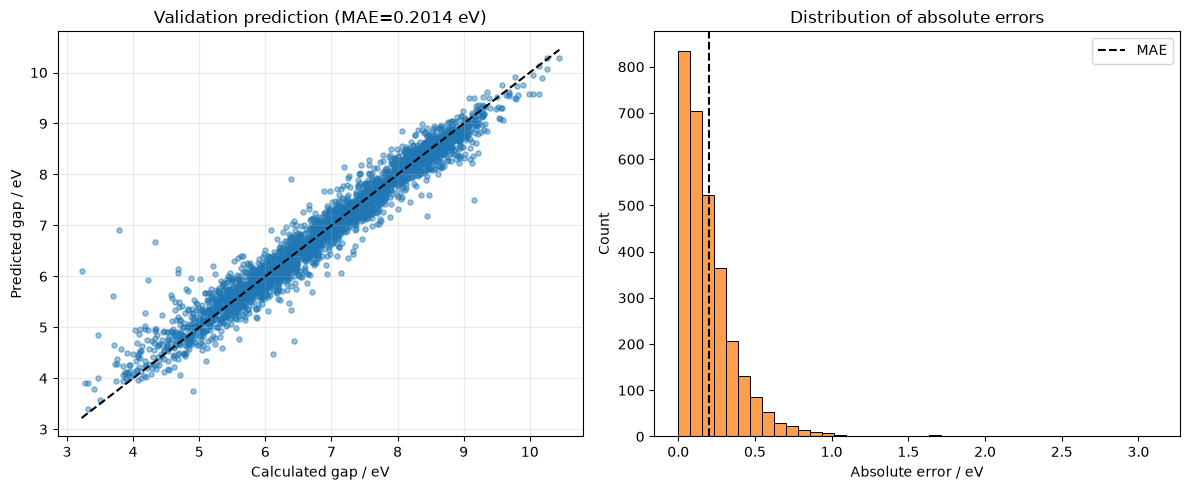

In [7]:
# 実測値と予測値の散布図、絶対誤差の分布を表示する
absolute_errors = np.abs(y_valid - valid_prediction)
plot_min = float(min(y_valid.min(), valid_prediction.min()))
plot_max = float(max(y_valid.max(), valid_prediction.max()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左図では、点が対角線に近いほど予測が正確である
axes[0].scatter(y_valid, valid_prediction, s=14, alpha=0.45, color="#1f77b4")
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "k--", linewidth=1.5)
axes[0].set_xlabel("Calculated gap / eV")
axes[0].set_ylabel("Predicted gap / eV")
axes[0].set_title(f"Validation prediction (MAE={validation_mae:.4f} eV)")
axes[0].grid(alpha=0.25)

# 右図では、誤差の大きい分子がどの程度あるかを確認する
sns.histplot(absolute_errors, bins=40, ax=axes[1], color="#ff7f0e")
axes[1].axvline(validation_mae, color="black", linestyle="--", label="MAE")
axes[1].set_xlabel("Absolute error / eV")
axes[1].set_title("Distribution of absolute errors")
axes[1].legend()

plt.tight_layout()
plt.show()

,feature,importance
225,graph_double_bonds,0.125608
102,FractionCSP3,0.120440
228,graph_conjugated_bonds,0.104096
221,graph_aromatic_atoms,0.046842
38,HallKierAlpha,0.039516
49,PEOE_VSA14,0.035435
180,fr_ketone,0.033827
227,graph_aromatic_bonds,0.030547
156,fr_amide,0.015822
152,fr_aldehyde,0.013893


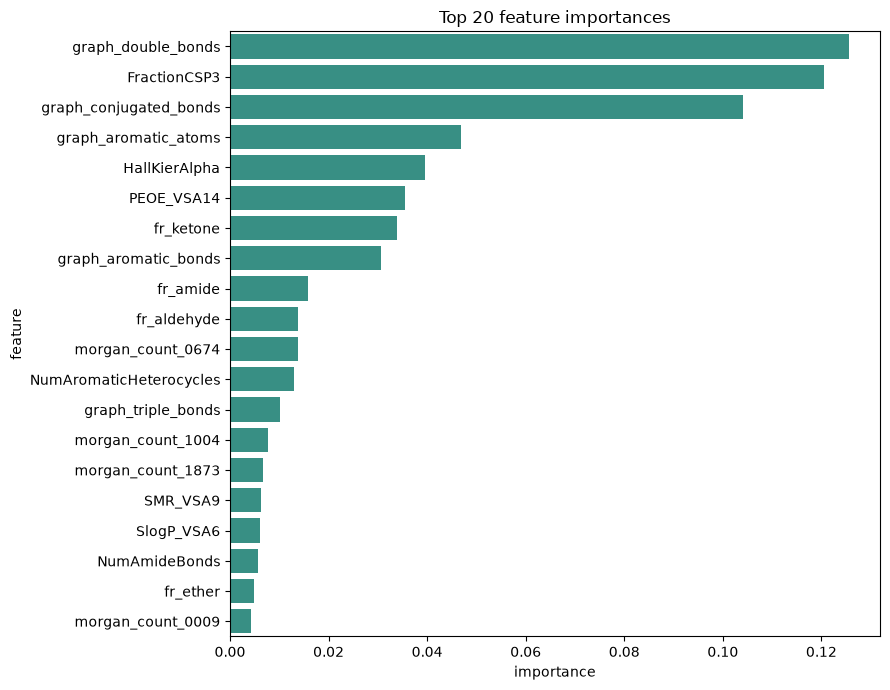

In [8]:
# 学習済みモデルの重要度から、寄与の大きい上位20特徴量を確認する
importance_df = pd.DataFrame(
    {
        "feature": FEATURE_NAMES,
        "importance": validation_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(9, 7))
sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature",
    color="#2a9d8f",
)
plt.title("Top 20 feature importances")
plt.tight_layout()
plt.show()

## 4. 全訓練データで学習し、提出CSVを作成

検証で決めた木の本数を固定し、正解値を持つ一意な全分子を使ってモデルをゼロから学習し直します。

テストデータのSMILES順を変えずに予測値を付け、`submissionv1.csv` として保存します。

In [9]:
# 最終学習では、欠損値の補完値を一意な全訓練データから計算する
final_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
X_full = final_imputer.fit_transform(X_all).astype(np.float32)
X_test_final = final_imputer.transform(X_test).astype(np.float32)

# 検証で選ばれた本数の木を持つXGBoostを、全訓練データからゼロから学習する
final_model = xgb.XGBRegressor(
    n_estimators=best_rounds,
    **XGB_PARAMS,
)
final_model.fit(X_full, y_all, verbose=False)

# 学習済み最終モデルの予測値だけを提出値として使用する
test_prediction = final_model.predict(X_test_final)

# 元のテストCSVのSMILESと行順をそのまま残し、gap_eV列を追加する
submission = test_df[["smiles"]].copy()
submission["gap_eV"] = test_prediction.astype(float)

# スライド指定の列名、行数、順序、有限値を保存前に検査する
assert submission.columns.tolist() == ["smiles", "gap_eV"]
assert len(submission) == len(test_df)
assert submission["smiles"].equals(test_df["smiles"])
assert np.isfinite(submission["gap_eV"]).all()

# 提出用CSVはインデックス列を付けずに保存する
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"保存先: {SUBMISSION_PATH}")
print(f"提出行数: {len(submission)}")
print(
    "予測値の範囲: "
    f"{submission['gap_eV'].min():.6f} ～ {submission['gap_eV'].max():.6f} eV"
)
display(submission.head())

保存先: /Users/f-kazuma/Developer/Python_seminer/9th/submissionv1.csv
提出行数: 4000
予測値の範囲: 3.624192 ～ 9.656164 eV


,smiles,gap_eV
0,CC1(CN1)C(C#C)C#N,7.301494
1,C1CC11C2OC2C11CO1,8.231673
2,OC1CC1C1CC(O)C1,8.614442
3,OC1C=CC2COC12,6.637943
4,CC1OC1CNC(N)=O,8.118265


In [10]:
# 保存したCSVを読み直し、ファイルとして壊れていないことを最終確認する
saved_submission = pd.read_csv(SUBMISSION_PATH)
assert saved_submission.columns.tolist() == ["smiles", "gap_eV"]
assert len(saved_submission) == len(test_df)
assert saved_submission["smiles"].equals(test_df["smiles"])
assert np.allclose(saved_submission["gap_eV"], submission["gap_eV"])

print("submissionv1.csvの再読込検査に合格しました。")

submissionv1.csvの再読込検査に合格しました。


## 口頭説明用の要点

- SMILESからRDKitの2次元分子記述子とMorganカウントフィンガープリントを生成しました。

- 重複分子による検証データへの漏洩を避けてから、シード8で学習用と検証用へ分割しました。

- XGBoostの木の本数を検証MAEによる早期停止で決めました。

- 最後に全訓練データでモデルを学習し直し、テストデータ4,000件の `gap_eV` を予測しました。